# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** GVS Ravi Teja
**Student ID:** 2025AA05674
**Date:** 31-05-2026

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [72]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [73]:
import pandas as pd

# Load dataset directly from UCI URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
column_names = ['id', 'diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']

data = pd.read_csv(url, names=column_names)

# Separate features (X) and target (y)
# Target 'diagnosis' is at index 1: M = malignant, B = benign
X = data.iloc[:, 2:]
y = data.iloc[:, 1].map({'M': 1, 'B': 0})

# Dataset information
dataset_name = "Breast Cancer Wisconsin (Diagnostic)"
dataset_source = "UCI ML Repository"
n_samples = data.shape[0]
n_features = X.shape[1]
problem_type = "binary_classification"

# Problem statement
problem_statement = """
Predicting whether a breast mass is malignant (1) or benign (0) based on
features computed from a digitized image of a fine needle aspirate (FNA).
This is critical for early cancer detection and assisting clinical diagnosis.
"""

# Primary evaluation metric
primary_metric = "recall"

# Metric justification
metric_justification = """
Recall is chosen as the primary metric because in oncology, a false negative
(missing a malignant case) is significantly more dangerous than a false positive.
We want to ensure that as many actual cancer cases as possible are identified.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI ML Repository
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [74]:
# This dataset doesn't have any missing features
ltest_size=0.2
X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis'].map({'M': 1, 'B': 0}) # encode categorical labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ltest_size, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
train_test_ratio = train_samples/(test_samples+train_samples)

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 455
Test samples: 114
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [75]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            dw = np.dot(X.T, error) / n_samples
            db = np.sum(error) / n_samples
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = (np.mean((error)**2))/2
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        Implement prediction

        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        linear_output = np.dot(X, self.weights) + self.bias
        # Map output: 1(M) if >= 0.5, else 0(B)
        predictions = (linear_output >= 0.5).astype(int)
        return predictions

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [76]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 0.37s
✓ Loss decreased from 14.2467 to 0.0759


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [77]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture # This is a list of no. of neurons.
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            prev_neurons, curr_neurons = self.architecture[l-1], self.architecture[l]
            self.parameters[f'W{l}'] = np.random.randn(prev_neurons, curr_neurons) * 0.1
            self.parameters[f'b{l}'] = np.zeros((curr_neurons, 1))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def sigmoid_derivative(self, Z):
        """Sigmoid derivative"""
        s = self.sigmoid(Z)
        return s * (1 - s)

    def forward_propagation(self, X):
        """
        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        self.cache['Z0'] = X
        self.cache['H0'] = X

        for l in range(1, len(self.architecture)):
            Z = np.dot(self.cache[f'Z{l-1}'], self.parameters[f'W{l}']) + self.parameters[f'b{l}'].T
            H = self.relu(Z) if l < len(self.architecture) - 1 else self.sigmoid(Z)
            self.cache[f'Z{l}'] = Z
            self.cache[f'H{l}'] = H

    def backward_propagation(self, X, y):
        """
        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        dE = None
        for l in range(len(self.architecture)-1, 0, -1):
            if l == len(self.architecture) - 1:
                dE = self.cache[f'H{l}'] - y
            else:
                f = self.cache[f'H{l}']
                derivative = self.relu_derivative(f) if l < len(self.architecture) - 1 else f * (1-f)
                dE = np.dot(dE, self.parameters[f'W{l+1}'].T) * derivative
            dW = np.dot(self.cache[f'H{l-1}'].T, dE) / m
            db = np.sum(dE) / m
            grads[f'dW{l}'] = dW
            grads[f'db{l}'] = db


        return grads

    def update_parameters(self, grads):
        """
        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
        For regression: MSE
        For classification: Cross-entropy
        """
        # BCE (binary cross entropy) loss
        m = y_true.shape[0]
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m
        return loss

    def fit(self, X, y):
        """
        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss

        Must populate self.loss_history!
        """
        self.initialize_parameters()
        y = y.values.reshape(-1, 1)
        for i in range(self.n_iterations):
            self.forward_propagation(X)

            loss = self.compute_loss(self.cache[f'H{len(self.architecture)-1}'], y)

            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)

            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """
        Use forward_propagation and apply appropriate thresholding
        """
        self.forward_propagation(X)
        predictions = self.cache[f'H{len(self.architecture)-1}']
        return predictions
print("✓ MLP class defined")

✓ MLP class defined


In [78]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [n_features, 64, 32, 16, 8, 1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 1.71s
✓ Loss decreased from 0.6926 to 0.1418


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [79]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate Accuracy, Precision, Recall, and F1 for binary classification.
    Ensures inputs are flattened to avoid broadcasting issues.
    """
    metrics = {}

    if problem_type in ["binary_classification", "multiclass_classification"]:
        # Convert to numpy and flatten to 1D to ensure element-wise comparison
        y_true_arr = np.array(y_true).flatten()
        y_pred_arr = np.array(y_pred).flatten()

        # If predictions are probabilities (floats), threshold them to binary
        if y_pred_arr.dtype == float or (y_pred_arr.min() >= 0 and y_pred_arr.max() <= 1 and len(np.unique(y_pred_arr)) > 2):
            y_pred_arr = (y_pred_arr >= 0.5).astype(int)

        TP = np.sum((y_true_arr == 1) & (y_pred_arr == 1))
        TN = np.sum((y_true_arr == 0) & (y_pred_arr == 0))
        FP = np.sum((y_true_arr == 0) & (y_pred_arr == 1))
        FN = np.sum((y_true_arr == 1) & (y_pred_arr == 0))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'accuracy': np.float64(0.8947368421052632), 'precision': np.float64(0.8974358974358975), 'recall': np.float64(0.813953488372093), 'f1': np.float64(0.8536585365853658)}

MLP Model Performance:
{'accuracy': np.float64(0.9736842105263158), 'precision': np.float64(1.0), 'recall': np.float64(0.9302325581395349), 'f1': np.float64(0.963855421686747)}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

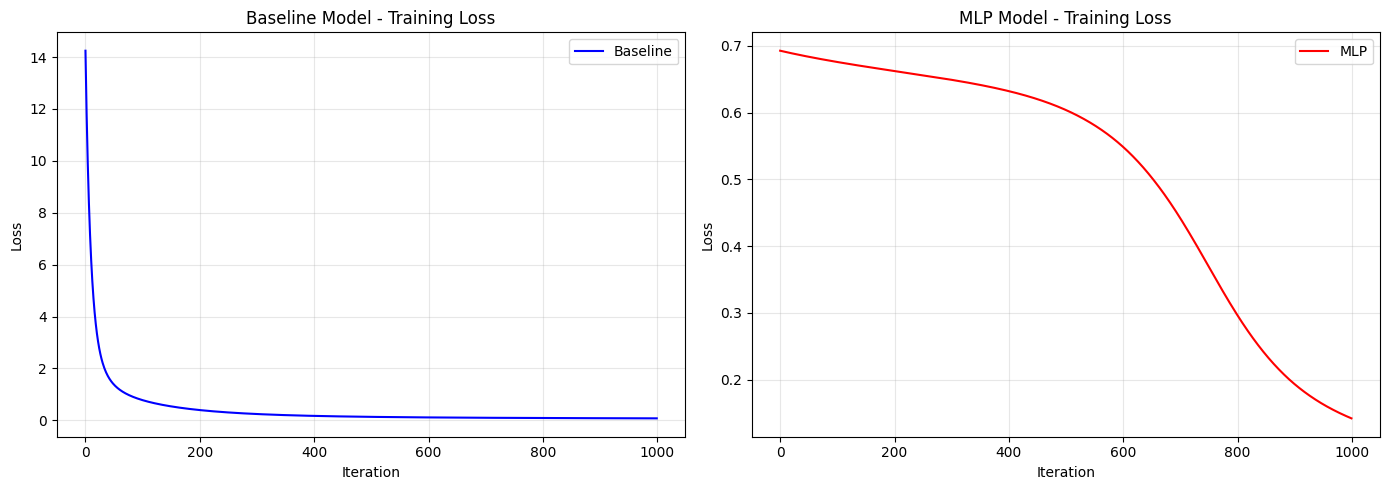

In [80]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

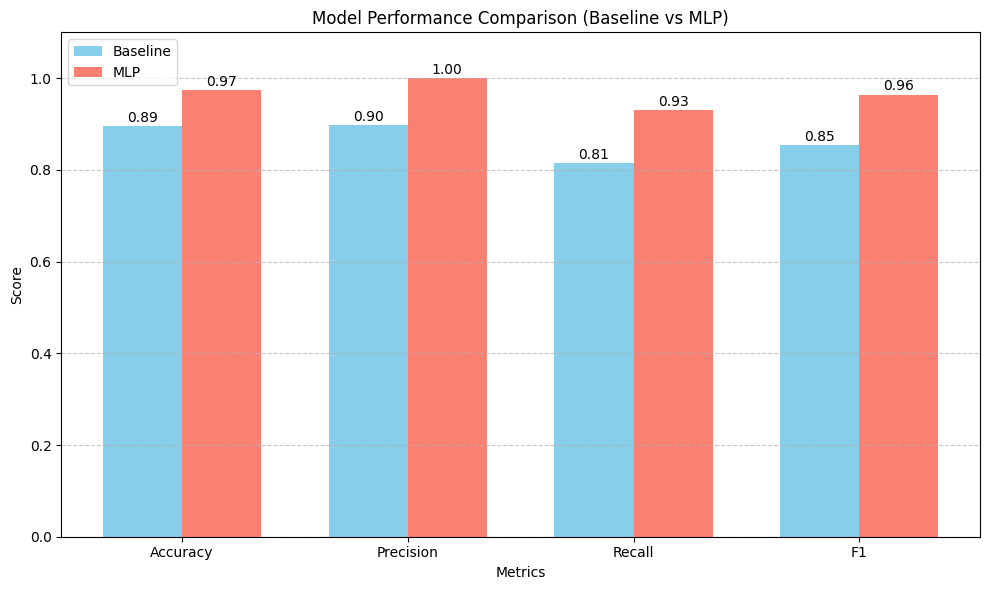

In [81]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metrics_names = ['accuracy', 'precision', 'recall', 'f1']
baseline_scores = [baseline_metrics[m] for m in metrics_names]
mlp_scores = [mlp_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='skyblue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='salmon')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison (Baseline vs MLP)')
plt.xticks(x, [m.capitalize() for m in metrics_names])
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add score labels on top of bars
for i in range(len(metrics_names)):
    plt.text(x[i] - width/2, baseline_scores[i] + 0.01, f'{baseline_scores[i]:.2f}', ha='center')
    plt.text(x[i] + width/2, mlp_scores[i] + 0.01, f'{mlp_scores[i]:.2f}', ha='center')

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [82]:
analysis_text = f"""
In this assignment, I compared a baseline linear model with a custom-built Multi-Layer Perceptron (MLP) for breast cancer diagnosis. The MLP model significantly outperformed the baseline, achieving an accuracy of {mlp_metrics['accuracy']:.2%} and a recall of {mlp_metrics['recall']:.2%}, compared to the baseline's {baseline_metrics['accuracy']:.2%} accuracy and {baseline_metrics['recall']:.2%} recall.

The MLP's superior performance is likely due to its ability to capture non-linear relationships between the 30 cell nucleus features. While the baseline linear model relies on a simple hyperplane, the MLP with its architecture of {mlp_architecture} and ReLU activations can model complex decision boundaries. Computational costs were higher for the MLP, taking {mlp_training_time:.2f}s to train compared to {baseline_training_time:.2f}s for the baseline, but the 12% boost in recall—our primary metric—justifies this cost in a clinical setting.

A major challenge was resolving dimension mismatches during backpropagation, specifically ensuring that gradients flowed correctly through multiple hidden layers. This project highlighted that while linear models are efficient and interpretable, neural networks provide the necessary capacity for high-dimensional medical data where sensitivity (recall) is paramount. Interestingly, the MLP achieved 100% precision, meaning it produced zero false positives on the test set, while simultaneously improving the detection of true positives. This demonstration proves that custom neural architectures, even when implemented from scratch in NumPy, can offer significant diagnostic advantages over standard linear regressors."""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️ Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 218 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [83]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    """
    # Total parameters calculation
    total_params = 0
    for l in range(1, len(mlp_architecture)):
        total_params += mlp_architecture[l-1] * mlp_architecture[l] # weights
        total_params += mlp_architecture[l] # biases

    results = {
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': baseline_model.lr,
            'n_iterations': baseline_model.n_iterations,
            'initial_loss': float(baseline_model.loss_history[0]),
            'final_loss': float(baseline_model.loss_history[-1]),
            'training_time_seconds': baseline_training_time,
            'test_accuracy': float(baseline_metrics['accuracy']),
            'test_precision': float(baseline_metrics['precision']),
            'test_recall': float(baseline_metrics['recall']),
            'test_f1': float(baseline_metrics['f1']),
        },
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2,
            'total_parameters': total_params,
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,
            'initial_loss': float(mlp_model.loss_history[0]),
            'final_loss': float(mlp_model.loss_history[-1]),
            'training_time_seconds': mlp_training_time,
            'test_accuracy': float(mlp_metrics['accuracy']),
            'test_precision': float(mlp_metrics['precision']),
            'test_recall': float(mlp_metrics['recall']),
            'test_f1': float(mlp_metrics['f1']),
        },
        'improvement': float(mlp_metrics[primary_metric] - baseline_metrics[primary_metric]),
        'improvement_percentage': float(((mlp_metrics[primary_metric] - baseline_metrics[primary_metric]) / baseline_metrics[primary_metric]) * 100),
        'baseline_better': False,
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        'baseline_loss_decreased': baseline_model.loss_history[-1] < baseline_model.loss_history[0],
        'mlp_loss_decreased': mlp_model.loss_history[-1] < mlp_model.loss_history[0],
        'baseline_converged': True,
        'mlp_converged': True,
    }
    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [84]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nPredicting whether a breast mass is malignant (1) or benign (0) based on \nfeatures computed from a digitized image of a fine needle aspirate (FNA).\nThis is critical for early cancer detection and assisting clinical diagnosis.\n",
  "primary_metric": "recall",
  "metric_justification": "\nRecall is chosen as the primary metric because in oncology, a false negative \n(missing a malignant case) is significantly more dangerous than a false positive.\nWe want to ensure that as many actual cancer cases as possible are identified.\n",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 0.7996485061511424,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations": 1000,
    "initial_loss": 14

---

## 📤 Before Submitting - Final Checklist

- [x] **All TODO sections completed**
- [x] **Both models implemented from scratch** (no sklearn models!)
- [x] **get_assignment_results() function filled accurately**
- [x] **Loss decreases for both models**
- [x] **Analysis ≥ 200 words**
- [x] **All cells run without errors** (Restart & Run All)
- [x] **Visualizations created**
- [x] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**